Hands-On Lab: Sprint 2 Close-Out        
● Step 1: Confirm and justify the core architecture for the project based on its data type.     
● Step 2: Train and tune the improved core model, logging each experiment's config and metric.      
● Step 3: Assemble a metric table comparing the Sprint 2 model to the Week 6 baseline and the Sprint 1 network.     
● Step 4: Ensure all Sprint 2 work is committed, the pull request is merged after mentor approval, and the notebook is documented.      
● Step 5: Present the Sprint Review, then write the Retrospective with one concrete change for Sprint 3     

I am going to continue on day3's LSTM and ECG heart Dataset.

also using the same dataset preprations as from day 3.

### Prepare the Dataset:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


Mounted at /content/drive


#### `Train-data`:

##### load df_train:

In [2]:
train_path = "/content/drive/MyDrive/Sprint 2 Dataset/mitbih_train.csv"

df_train = pd.read_csv(train_path, header=None) # header=None because this dataset does not use a normal header row

print(df_train.shape)
df_train.head()

(87554, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# checking the Last column (the heartbeat class label.)
print(df_train.iloc[:, -1].value_counts())

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


| Label | General meaning               |
| ----: | ----------------------------- |
|   `0` | Normal beat                   |
|   `1` | Supraventricular ectopic beat |
|   `2` | Ventricular ectopic beat      |
|   `3` | Fusion beat                   |
|   `4` | Unknown / other beat          |


In [4]:
# everything except the last column belongs to the ECG sequence

print("Number of signal values:", df_train.shape[1] - 1) # columns -1 label column
print("Number of samples:", df_train.shape[0]) # rows

# So each row is: 187 ECG measurements + 1 label column

Number of signal values: 187
Number of samples: 87554


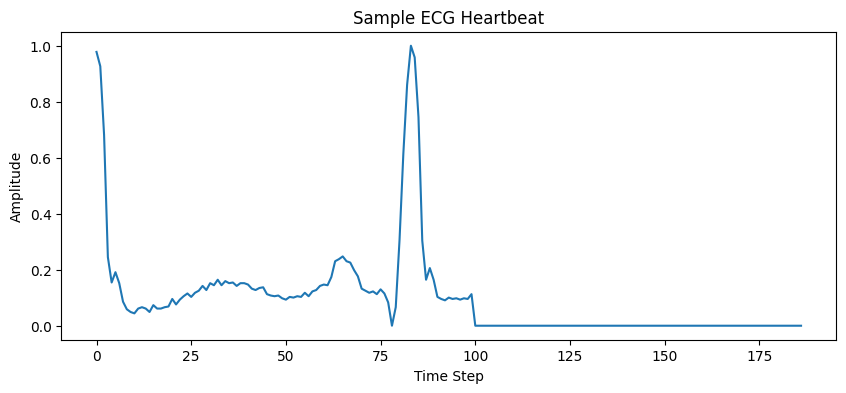

In [5]:
# inspecting one signal (-one row- without the last column, which is the label column.)
sample_signal = df_train.iloc[0, :-1]

plt.figure(figsize=(10, 4))
plt.plot(sample_signal)
plt.title("Sample ECG Heartbeat")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

##### Split into X_train & y_train

In [6]:
X_train = df_train.iloc[:,:-1] # all columns except the last one (contains only the ECG signal values.)

y_train = df_train.iloc[:, -1] # contains the heart beat class label.



y_train = y_train.astype(int) # turn it into integers ince they are class id's (makes them easier to read)


In [7]:
print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

print(y_train.value_counts())

X shape: (87554, 187)
y shape: (87554,)
187
0    72471
4     6431
2     5788
1     2223
3      641
Name: count, dtype: int64


In [8]:
# checking the all values across time stamps for the (first row)
print(X_train.iloc[0])

0      0.977941
1      0.926471
2      0.681373
3      0.245098
4      0.154412
         ...   
182    0.000000
183    0.000000
184    0.000000
185    0.000000
186    0.000000
Name: 0, Length: 187, dtype: float64


This gives the 187 values of the first heartbeat. (first row)

sample 0:

[0.97, 0.92, 0.68, 0.24, 0.15, ...]     
Each number is one point in the sequence.   
`order matters ! `

In [9]:
# checking the label of the (first row)
print("Class:", y_train.iloc[0])

Class: 0


##### Reshaping (Suiting) X_train & y_train for keras:

`RNN layers expect three dimensions` (samples, timesteps, features).     
our current shape is (samples, timesteps).
     
`note`: we only have 1 features because at each time stamp we only have 1 feature recorded (ECG amplitude).     

In [10]:
# pandas objects are not compatible with keras,
# so they need to be converted to numpy arrays first.

X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [11]:
print("X_train shape before reshaping :", X_train.shape)

X_train = X_train.reshape(X_train.shape[0] ,  X_train.shape[1] ,  1)

print("X_train shape after reshaping :", X_train.shape)

X_train shape before reshaping : (87554, 187)
X_train shape after reshaping : (87554, 187, 1)


A sample is a sequence of 187 time steps, and each time step contains 1 feature.

#### `Test-data`:

##### load df_test:

In [12]:

test_path = "/content/drive/MyDrive/Sprint 2 Dataset/mitbih_test.csv"

df_test = pd.read_csv(test_path,header=None) # header=None because this dataset does not use a normal header row

print(df_test.shape)
df_test.head()

(21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# checking the Last column (the heartbeat class label.)
print(df_test.iloc[:, -1].value_counts())

187
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64


| Label | General meaning               |
| ----: | ----------------------------- |
|   `0` | Normal beat                   |
|   `1` | Supraventricular ectopic beat |
|   `2` | Ventricular ectopic beat      |
|   `3` | Fusion beat                   |
|   `4` | Unknown / other beat          |


In [14]:
# everything except the last column belongs to the ECG sequence

print("Number of signal values:", df_test.shape[1] - 1) # columns -1 label column
print("Number of samples:", df_test.shape[0]) # rows

# So each row is: 187 ECG measurements + 1 label column

Number of signal values: 187
Number of samples: 21892


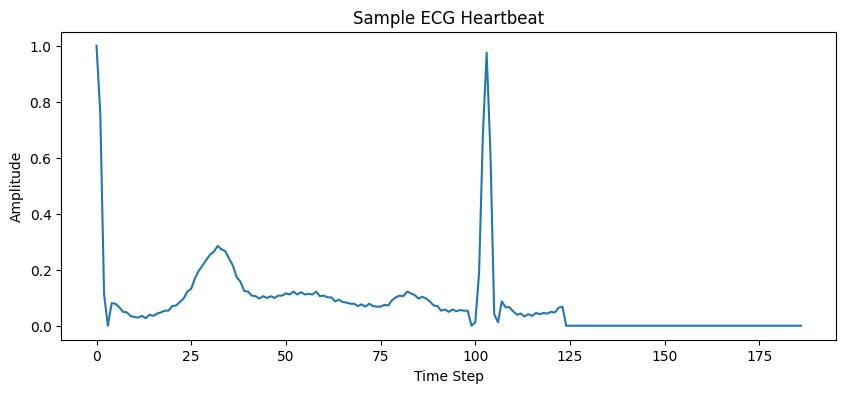

In [15]:
# inspecting one signal (-one row- without the last column, which is the label column.)
sample_signal = df_test.iloc[0, :-1]

plt.figure(figsize=(10, 4))
plt.plot(sample_signal)
plt.title("Sample ECG Heartbeat")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

##### Split into X_test & y_test

In [16]:
X_test = df_test.iloc[:,:-1] # all columns except the last one (contains only the ECG signal values.)

y_test = df_test.iloc[:, -1] # contains the heart beat class label.



y_test = y_test.astype(int) # turn it into integers ince they are class id's (makes them easier to read)


In [17]:
print("X shape:", X_test.shape)
print("y shape:", y_test.shape)

print(y_test.value_counts())

X shape: (21892, 187)
y shape: (21892,)
187
0    18118
4     1608
2     1448
1      556
3      162
Name: count, dtype: int64


In [18]:
print(X_test.iloc[0])

0      1.000000
1      0.758264
2      0.111570
3      0.000000
4      0.080579
         ...   
182    0.000000
183    0.000000
184    0.000000
185    0.000000
186    0.000000
Name: 0, Length: 187, dtype: float64


This gives the 187 values of the first heartbeat. (first row)

sample 0:

[0.93, 0.87, 0.64, 0.41, 0.29, ...]     
Each number is one point in the sequence.   
`order matters ! `

In [19]:
print("Class:", y_test.iloc[0])

Class: 0


##### Reshaping (Suiting) X_test & y_test for keras:

our `currnt shape` is (21892, 187).       
Still this can't be given to keras right now.        
 since it `RNN layers expect three dimensions` (samples, timesteps, features).        

So for test data set we should have :       
samples = 21892     
timesteps = 187     
features = 1        

`note`: features = 1  , because at each time stamp we only have one measurement (ECG amplitude)


In [20]:
# pandas objects are not compatible with keras,
# so they need to be converted to numpy arrays first.

X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

print(type(X_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [21]:
print("X_test shape before reshaping :", X_test.shape)

X_test = X_test.reshape(X_test.shape[0] ,  X_test.shape[1] ,  1)

print("X_test shape after reshaping :", X_test.shape)

X_test shape before reshaping : (21892, 187)
X_test shape after reshaping : (21892, 187, 1)


#### `Fixes before models`:

##### Explicitly stratified validation set:

In [22]:
X_train_split , X_val, y_train_split , y_val = train_test_split(X_train, y_train, test_size=.2, random_state=42, stratify= y_train)

In [23]:
# check that it worked

print("Training classes:")
print( np.unique( y_train_split, return_counts=True) )

print("\nValidation classes:")
print( np.unique( y_val, return_counts=True) )

Training classes:
(array([0, 1, 2, 3, 4]), array([57977,  1778,  4630,   513,  5145]))

Validation classes:
(array([0, 1, 2, 3, 4]), array([14494,   445,  1158,   128,  1286]))


##### Class weights balance:

Since `y_train` classes are highly imbalanced or skewed.    
class weighting would be of benefit.    

**Note**: since we are now training on `y_train_split` it will `replace` `y_train`.

In [24]:
# compute the weight for each unique class in `y_train_split`.

classes = np.unique(y_train_split)

weights = compute_class_weight( class_weight = "balanced",  classes = classes,   y = y_train_split)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.2416234023837039), np.int64(1): np.float64(7.878852643419573), np.int64(2): np.float64(3.0256155507559397), np.int64(3): np.float64(27.307212475633527), np.int64(4): np.float64(2.722759961127308)}


balanced Class weights for y_train:     
0 : 0.24     
1 : 7.87     
2 : 3.02     
3 : 27.31        
4 : 2.72     

**Note**: `since stratify was used`, `even though y_train_split replaced y_train` the class weights are the same.

### LSTM

In [25]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

#### Tuned LSTM Model:

In [26]:
# Model
final_lstm = Sequential([
    Input(shape = (187,1)),

    LSTM(128),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(5,activation="softmax")
])

In [27]:
# Compile
final_lstm.compile(
    optimizer=Adam(learning_rate=0.0001), # to avoid the model overshooting or oscilating, a smaller learning rate is used
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
# Early stopping to prevent overfitting and save time
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [39]:
# trying to test less aggrisive class weights
# those will be used since they give better results !
soft_class_weights = {
    0: 1.0,
    1: 2.0,
    2: 1.5,
    3: 3.0,
    4: 1.5
}

In [40]:
# Fit (Train)
history_final = final_lstm.fit(
    X_train_split,
    y_train_split,

    validation_data=(X_val, y_val),

    epochs=25,
    batch_size=64,

    class_weight= soft_class_weights,
    callbacks=[early_stop]
)

Epoch 1/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.7760 - loss: 1.0470 - val_accuracy: 0.8277 - val_loss: 0.6715
Epoch 2/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8245 - loss: 0.9512 - val_accuracy: 0.8277 - val_loss: 0.6535
Epoch 3/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8226 - loss: 0.9375 - val_accuracy: 0.8277 - val_loss: 0.6247
Epoch 4/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8253 - loss: 0.9234 - val_accuracy: 0.8376 - val_loss: 0.6067
Epoch 5/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8323 - loss: 0.8884 - val_accuracy: 0.8354 - val_loss: 0.5738
Epoch 6/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8333 - loss: 0.8723 - val_accuracy: 0.8240 - val_loss: 0.6150
Epoch 7/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8277 - loss: 0.9043 - val_accuracy: 0.8277 - val_loss: 0.6042
Epoch 8/25
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8326 -

#### Plots:

- Loss plot

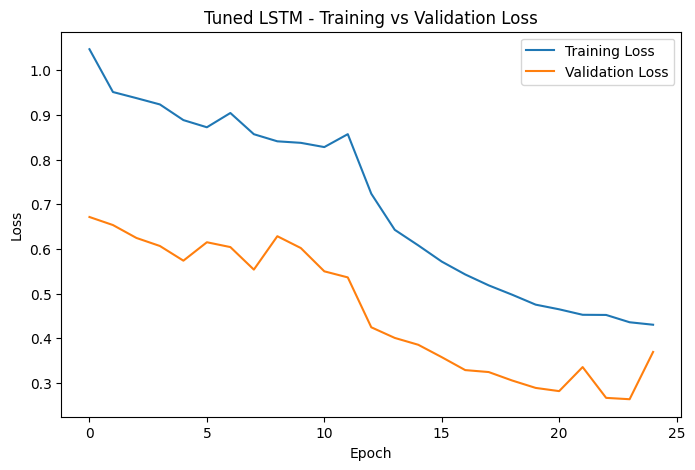

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["loss"], label="Training Loss")

plt.plot(history_final.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Tuned LSTM - Training vs Validation Loss")

plt.legend()

plt.show()

- Accuracy plot

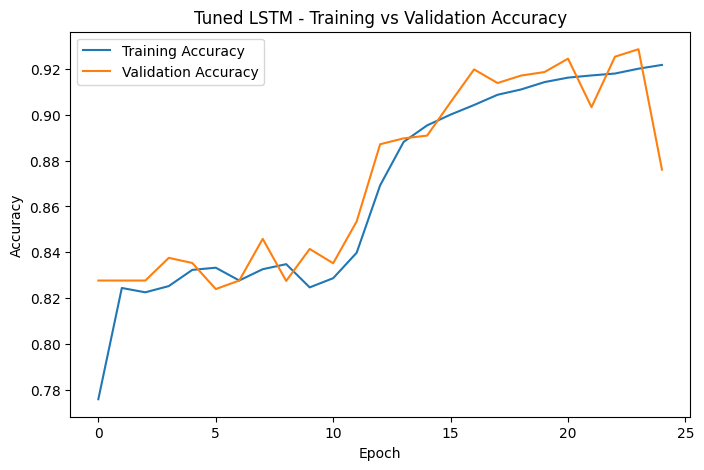

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["accuracy"], label="Training Accuracy")

plt.plot(history_final.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Tuned LSTM - Training vs Validation Accuracy")

plt.legend()

plt.show()

#### Evaluation:

In [57]:
# Predict on the test set

y_pred_prob_final = final_lstm.predict(X_test)

y_pred_final = np.argmax(y_pred_prob_final, axis=1)

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [58]:
# calculate Metrics

accuracy_final = accuracy_score(y_test, y_pred_final)

precision_final = precision_score(y_test, y_pred_final, average="macro", zero_division=0)

recall_final = recall_score( y_test, y_pred_final, average="macro", zero_division=0)

f1_final = f1_score( y_test, y_pred_final, average="macro",  zero_division=0)


print("Accuracy:", accuracy_final)

print("Macro Precision:",precision_final)

print("Macro Recall:",recall_final)

print("Macro F1-score:",f1_final)

Accuracy: 0.9270966563128084
Macro Precision: 0.7106512859446446
Macro Recall: 0.6427815964311402
Macro F1-score: 0.6711619585014057


In [59]:
# Classification report
print("\nClassification Report:\n")

print(classification_report( y_test, y_pred_final, digits=4, zero_division=0))


Classification Report:

              precision    recall  f1-score   support

           0     0.9505    0.9737    0.9620     18118
           1     0.6438    0.4227    0.5103       556
           2     0.8095    0.6927    0.7466      1448
           3     0.2733    0.2716    0.2724       162
           4     0.8761    0.8532    0.8645      1608

    accuracy                         0.9271     21892
   macro avg     0.7107    0.6428    0.6712     21892
weighted avg     0.9229    0.9271    0.9240     21892



In [60]:
# confusion matrix

cm_final = confusion_matrix( y_test, y_pred_final)
print (cm_final)


[[17642    95   145    82   154]
 [  307   235    12     0     2]
 [  350    24  1003    33    38]
 [   96     1    21    44     0]
 [  166    10    58     2  1372]]


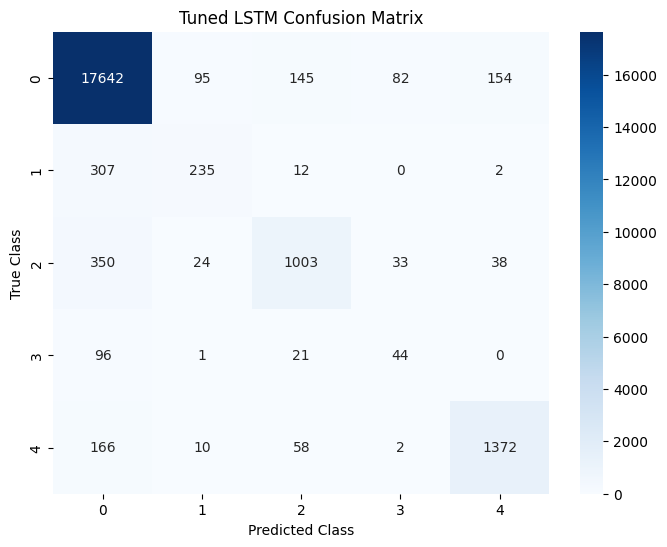

In [61]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title("Tuned LSTM Confusion Matrix")

plt.show()

In [62]:
final_lstm.summary() # model summary (parameters)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,425 (880.57 KB)

 Trainable params: 75,141 (293.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 150,284 (587.05 KB)

#### Findings (Conclusion)

 `Tuned LSTM Evaluation`

The tuned LSTM `using automatically balanced class weights performed poorly overall`, with an accuracy of approximately `6.6%` and a macro F1-score of `0.083`.

The confusion matrix showed that the model strongly over-predicted minority class `3`. Although class `3` achieved a recall of approximately `0.975`, its precision was only around `0.011`, meaning many samples from other classes were incorrectly classified as class `3`.

At the same time, the majority class `0` achieved only `0.005` recall.

This suggests that the `automatically calculated class weights over-corrected the class imbalance` and caused the model to favor rare classes too strongly.

Therefore, a more moderate weighting strategy is needed.


 **`Final Tuned LSTM Results`**

The final tuned LSTM used `128 LSTM units`, dropout regularization, a smaller learning rate, early stopping, and manually softened class weights.

The model achieved a test accuracy of approximately `92.7%`, with a macro precision of `0.711`, macro recall of `0.643`, and macro F1-score of `0.671`.

Compared with the previous automatically balanced model, the softened class weights produced a much better balance between majority and minority classes.       
 The model correctly classified most samples from classes `0`, `2`, and `4`, while classes `1` and especially `3` remained more difficult.      

Class `3` achieved the weakest F1-score at approximately `0.272`, which is likely related to its very small number of training examples.        

Overall, the final tuned LSTM provided the strongest and most balanced performance obtained for the ECG classification task.        


 **`Final Core Model Decision`**

The `tuned LSTM with softened class weights` was selected as the final Sprint 2 core model.

Earlier experiments showed that automatically calculated class weights over-corrected the imbalance and caused the model to strongly favor rare classes. After replacing these with more moderate class weights and tuning the LSTM architecture, the model achieved approximately `92.7% test accuracy` and a macro F1-score of `0.671`.

The LSTM is also appropriate for the ECG dataset because each heartbeat is an ordered time-series sequence, and LSTMs are designed to learn temporal relationships across sequential measurements.

Therefore, the tuned LSTM provides the best combination of architecture suitability, generalization, and balanced classification performance.
